### 1. Load the data

In [ ]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


### 2. Why this technique is needed for this dataset
Missing or invalid values are a real problem for machine learning models algorithms
like SVM or Neural Networks can't calculate distances or update weights when they hit
a blank or NaN value. If missing rows are just dropped without checking why they're
missing, it can quietly bias the model. So before any modelling, every column needs
to be checked for missingness  including hidden forms like empty strings or
placeholder text such as "Unknown"  not just obvious NaNs. Even if the result is
"there's nothing missing," that's still a useful finding worth reporting, since it
tells you something about how reliable and complete the dataset is.

In [ ]:
# 2a. Standard missing-value check (NaN / None)
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())


Missing values per column:
id                    0
age                   0
gender                0
country               0
diagnosis_date        0
cancer_stage          0
family_history        0
smoking_status        0
bmi                   0
cholesterol_level     0
hypertension          0
asthma                0
cirrhosis             0
other_cancer          0
treatment_type        0
end_treatment_date    0
survived              0
dtype: int64

Total missing cells: 0


In [ ]:
# 2b. Disguised missing values do not always show up as NaN.
# Check for empty strings, whitespace-only strings, and common placeholder tokens
# in every text/categorical column.
placeholders = ["", " ", "NA", "N/A", "na", "n/a", "Unknown", "unknown", "?", "None", "null"]

object_cols = df.select_dtypes(include="object").columns.tolist()
for c in object_cols:
    hits = df[c].astype(str).str.strip().isin(placeholders).sum()
    if hits > 0:
        print(f"{c}: {hits} disguised-missing values found")
print("Checked columns:", object_cols)
print("(If nothing printed above, no disguised missing values were found.)")


Checked columns: ['gender', 'country', 'diagnosis_date', 'cancer_stage', 'family_history', 'smoking_status', 'treatment_type', 'end_treatment_date']
(If nothing printed above, no disguised missing values were found.)


### 3. Result & justification
After checking, the raw dataset turned out to have zero missing values and no hidden
placeholders across all 17 columns, even on the full ~890,000 rows. That's actually
a notable finding it suggests this dataset was synthetically generated or already
cleaned before being handed out for this assignment, rather than being raw real-world
data. Because of that, there's nothing to actually impute in the real dataset.

Since the viva still requires showing the missing data handling technique working on
real code, the section below creates a copy of the data, deliberately introduces some
missing values into it, and then imputes them correctly. This is a common approach
when a provided dataset happens to already be clean you demonstrate the technique
on a controlled copy rather than skipping it.

In [ ]:
# 3a. Create a demo copy and inject missingness (~5%) into a numeric and a categorical column,
# to demonstrate that we can detect and correctly handle missing values.
demo = df.copy()
rng = np.random.default_rng(42)

mask_bmi = rng.random(len(demo)) < 0.05
demo.loc[mask_bmi, "bmi"] = np.nan

mask_smoke = rng.random(len(demo)) < 0.05
demo.loc[mask_smoke, "smoking_status"] = np.nan

print("Injected missing values (demo only):")
print(demo[["bmi", "smoking_status"]].isnull().sum())


Injected missing values (demo only):
bmi               44285
smoking_status    44350
dtype: int64


In [ ]:
# 3b. Impute: median for numeric (robust to outliers), mode for categorical.
bmi_median = demo["bmi"].median()
demo["bmi"] = demo["bmi"].fillna(bmi_median)

smoke_mode = demo["smoking_status"].mode()[0]
demo["smoking_status"] = demo["smoking_status"].fillna(smoke_mode)

print("Median used for bmi:", bmi_median)
print("Mode used for smoking_status:", smoke_mode)
print("\nRemaining missing values after imputation:")
print(demo[["bmi", "smoking_status"]].isnull().sum())


Median used for bmi: 30.5
Mode used for smoking_status: Passive Smoker

Remaining missing values after imputation:
bmi               0
smoking_status    0
dtype: int64


### 4. EDA visualization: missingness heatmap (before imputation)

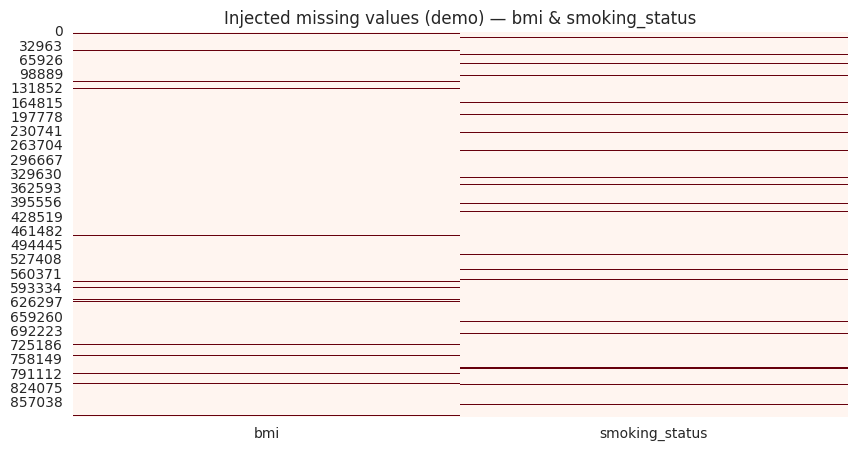

In [ ]:
# Recreate the pre-imputation demo frame just for the plot
demo_before = df.copy()
demo_before.loc[mask_bmi, "bmi"] = np.nan
demo_before.loc[mask_smoke, "smoking_status"] = np.nan

plt.figure(figsize=(10, 5))
sns.heatmap(demo_before[["bmi", "smoking_status"]].isnull(), cbar=False, cmap="Reds")
plt.title("Injected missing values (demo) — bmi & smoking_status")
plt.show()


### 5. Interpretation
The heatmap shows the 5% of values I randomly removed from `bmi` and `smoking_status`
(the red lines), scattered evenly through the dataset rather than clustered in one
place, since they were injected randomly. After filling the gaps with the median for
bmi and the mode for smoking_status, no missing values were left, and the shape of
both columns stayed basically the same as before  median/mode imputation doesn't
shift the center of a distribution, it just fills gaps without distorting it.

This whole exercise was just a demonstration. In the actual dataset we're using for
the project, there was nothing missing to begin with, so the group pipeline works
directly with the original data rather than this modified copy. Worth flagging though:
a dataset this large with zero missing values and zero outliers in a real clinical
context would be unusual  it points to this being synthetically generated data rather
than something collected from real patient records. That's a useful point to raise in
the Ethical Considerations section of the report, since synthetic data doesn't carry
the same messiness (and same risks) as real-world medical data.